# MemoryNPC: A LangChain-Powered NPC Dialogue Agent with Long-Term Memory

This notebook documents and validates a small NLP project called **MemoryNPC**. The project is not meant to be a full game. It is an NLP agent for a specific language-rich task: turning a stream of player dialogue into classified intents, durable memories, semantic retrieval results, relationship state, and grounded character responses.

The project is intentionally scoped so it can be finished in less than 24 hours. The application is only a demo surface; the main contribution is the pipeline built on top of an LLM. A normal chat model can roleplay Elara, but it cannot reliably manage persistent memory, retrieval tests, and deterministic relationship tracking out of the box.

## 1. Design challenge

Design a LangChain-based NPC memory agent to enable players in narrative game contexts to interact with non-player characters that remember previous conversations, retrieve relevant memories, and respond with context-aware dialogue with at least 80% memory retrieval success on manually designed test cases.

## 2. NLP task and novelty

The NLP task is **context-aware NPC dialogue with external long-term memory**. This is different from simply asking ChatGPT to pretend to be a blacksmith. The agent has to process player language into structured intermediate outputs before it generates a reply.

The pipeline performs several NLP operations:

- **Intent detection:** classify the player's utterance into a restricted label set such as `ask_memory`, `share_fact`, `compliment`, or `insult`.
- **Information extraction:** decide whether the utterance contains a durable memory worth saving, and rewrite it as a short memory sentence.
- **Semantic representation:** convert stored memories and new queries into embedding vectors.
- **Vector retrieval:** use FAISS to retrieve memories by meaning instead of exact words.
- **State tracking:** update a deterministic trust score from the detected intent.
- **Controlled natural language generation:** prompt the chat model with retrieved memories and state so Elara responds in character without inventing unsupported memories.

The novelty is therefore not the web interface. The novelty is chaining language understanding, information extraction, semantic search, symbolic state, and generation into one small agent that solves a task an LLM alone is not reliable at: persistent, testable NPC memory.

## 3. Problem background

Traditional game NPCs often use fixed dialogue trees. This makes them reliable, but also predictable. If the player says something unusual, the NPC usually cannot adapt. Modern LLMs can generate much more natural dialogue, but a plain LLM call is not automatically a good memory system.

For narrative games, memory matters because the player expects social consequences. If the player says their name, loses a sword, helps the village, or insults the blacksmith, the NPC should be able to use that information later. This makes the interaction feel less like a disconnected chatbot and more like a continuing relationship.

## 4. Why an LLM alone is not enough

A normal LLM by itself is not reliable as a persistent memory system. It only sees the context that is passed into the current prompt. As the conversation grows, the context can become too long, expensive, or noisy. The model may also forget details, invent false memories, or mix up old facts. It also does not automatically expose intermediate outputs like intent labels, extracted memories, retrieval hits, or relationship scores that can be inspected and evaluated.

This project separates the system into smaller parts. The LLM is used where language flexibility is useful, especially extraction and response generation, but memory and trust are handled explicitly. Durable facts are extracted and stored. FAISS retrieves memories using embeddings, which means retrieval can work semantically instead of requiring exact keyword matches. The trust score is deterministic, so it can be tested and explained. LangChain helps connect these steps in a modular pipeline without turning the project into a large framework.

## 5. Design considerations and motivated choices

### Why LangChain?

LangChain is useful here because the project is not just one prompt. It has several small NLP stages: classify intent, extract memory, retrieve documents, and generate a final response. LangChain prompt templates make these stages easier to keep separate and readable. This is important for the assignment because the architecture should be explainable, not hidden in one giant prompt. It also reflects how many real NLP systems are built: general models are combined with retrieval, structured state, and task-specific logic.

### Why an OpenAI chat model?

The chat model is used for natural dialogue and for small language-understanding steps. Elara needs to sound like a cautious village blacksmith, not just return database facts. A cheap and fast model is enough because the task is a prototype and the prompt gives a narrow role, retrieved memories, and a trust score. The important point is that the chat model is not trusted to do every part of the system silently; it is one component in a larger NLP chain.

### Why embeddings?

A memory system should retrieve meaning, not only matching words. If the memory says "the player lost a sword near the forest" and later the player asks "what weapon did I misplace by the trees?", keyword search may fail. Embeddings represent text semantically, so related meanings can still be close.

### Why FAISS?

FAISS is a simple vector store for similarity search. It is suitable for this assignment because it is local, fast, and easy to connect through `langchain_community.vectorstores`. For a bigger game this could be replaced by a persistent vector database, but FAISS is enough for a notebook and Streamlit demo.

### Why separate memory extraction?

Not every chat message should become a memory. If the player says "hello" or makes filler conversation, saving it would pollute the memory store. A separate extraction step asks the model to save only durable memories such as names, goals, lost items, insults, favors, or preferences. This turns raw dialogue into a cleaner knowledge representation that retrieval can use later.

### Why a trust score?

A relationship score gives the NPC consistent social behavior. Compliments raise trust, insults lower it, and neutral requests do not change it. This is deliberately deterministic because it makes the system easy to test and avoids leaving relationship logic entirely to the LLM.

### Why Streamlit?

Streamlit is quick for a live demo. It can keep the agent in session state, show the conversation, and expose internal state like memories and trust score in the sidebar. That makes the pipeline visible for assessment.

### Why notebook-based validation?

The notebook is where the project becomes more than a demo. It explains the design, runs manual tests, calculates intent accuracy, checks retrieval success, plots trust behavior, and discusses errors. This matters because LLM systems need validation, not only nice examples.

### Design questions a teacher might ask

**What does the LLM do, and what does the system around it do?** The LLM handles flexible language tasks: extracting memories and generating Elara's final response. The surrounding pipeline handles structure: intent labels, vector storage, retrieval, trust rules, and validation tables.

**Why is this not just a chatbot?** A chatbot can answer a prompt, but this agent stores selected memories, retrieves them later, exposes intermediate decisions, and changes relationship state with deterministic rules.

**What does the trust score do?** It converts social language and player behavior into a simple relationship state. Compliments, insults, greetings, shared facts, and advice-following can change the score. The score is injected into the prompt so Elara's tone can become guarded, neutral, or warm.

**Is there a threshold where behavior changes?** Yes. Below 40 is low trust, 40-69 is neutral trust, and 70+ is high trust. These bands are used as prompt instructions. I kept the thresholds simple because the goal is explainability rather than realistic psychology.

**Why store trust impact in memory metadata if the trust score already changes?** The metadata makes validation easier. If a compliment is saved, the table can show that this memory had `trust_impact = +5`. If the player ignores advice, the trace can show an `advice_delta`. That connects the stored event to the relationship update.

**Why retrieve only top-k memories?** Injecting every memory would make prompts longer and noisier. Top-k retrieval keeps the response grounded in a small amount of relevant evidence.

**What is the main risk?** The main risk is that the LLM may produce a fluent but unsupported answer. The prompt reduces this by telling Elara not to claim memories unless they appear in the retrieved memory list, and the validation trace lets me inspect whether that happened.

## 6. Architecture diagram

```mermaid
flowchart TD
    A[Player Input] --> B[Intent Detection Chain]
    B --> C[Memory Extraction Chain]
    C --> D[FAISS Vector Memory Store]
    A --> E[Memory Retrieval]
    D --> E
    B --> F[Trust Score Update]
    E --> G[Prompt Builder]
    F --> G
    G --> H[OpenAI Chat Model]
    H --> I[NPC Response]
```

This is a retrieval-augmented generation architecture for NPC memory. The final response is generated by an LLM, but the LLM is grounded by retrieved memory documents and guided by structured state. The diagram also shows why this is an NLP pipeline rather than a simple chatbot: each stage transforms language into a different representation before the final answer is produced.

## 7. Implementation overview

The project has three main files:

- `npc_agent.py` contains the reusable `MemoryNPC` class. This is where intent detection, memory extraction, FAISS storage, retrieval, trust scoring, and response generation are implemented.
- `app.py` contains the Streamlit interface. It keeps the agent alive in `st.session_state` and shows internal state in the sidebar, including a validation trace of every turn.
- `notebook.ipynb` explains the project and runs validation tests.

The shared backend keeps the notebook and app consistent. This also makes the code easier to inspect because the app is not hiding the main logic. In other words, the Streamlit interface is only a way to interact with the pipeline; the pipeline itself is implemented in `npc_agent.py`. The app also logs each turn for validation: player input, detected intent, extracted memory, saved memory, retrieved memories, trust before/after, trust delta, and NPC response.

## 8. Setup

The project uses an environment variable called `OPENAI_API_KEY`. Create a `.env` file in this folder using `.env.example` as a template before running the cells that call the model.

In [1]:
# Standard library and plotting/table tools used for setup and validation.
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# MemoryNPC contains the reusable pipeline. The notebook imports it instead of
# duplicating logic so the report and Streamlit app test the same code.
from npc_agent import MemoryNPC

# Load the API key from .env. The notebook prints only a boolean so the key is
# never exposed in the report output.
load_dotenv()
print('API key loaded:', bool(os.getenv('OPENAI_API_KEY')))

API key loaded: True


In [2]:
# Create a fresh agent so the demo starts with empty memory and neutral trust.
agent = MemoryNPC()
print('Elara is ready. Starting trust:', agent.trust_score)

Elara is ready. Starting trust: 50


## 9. Manual demo conversation

This conversation is designed to exercise the full pipeline. It includes greeting, sharing a name, reporting a lost item, asking for help, complimenting Elara, asking memory questions, asking for a quest, insulting her, and saying goodbye.

In [3]:
# This scripted conversation is chosen to exercise the whole pipeline:
# greeting, memory extraction, retrieval, trust increase, trust decrease, and goodbye.
demo_inputs = [
    'Hello Elara',
    'My name is Matt',
    'I lost my sword near the forest',
    'Can you help me?',
    'You are a very skilled blacksmith',
    'Do you remember what I lost?',
    'I need a quest',
    'You are useless',
    'Can you still help me?',
    'Goodbye',
]

# Store each returned turn record so the notebook can show internal pipeline
# decisions, not only the final NPC text.
demo_rows = []
for message in demo_inputs:
    result = agent.generate_npc_response(message)
    demo_rows.append(result)

# Convert the turn records into a compact table for the report.
demo_df = pd.DataFrame(demo_rows)[[
    'turn', 'player_input', 'intent', 'retrieved_memories', 'trust_score', 'npc_response'
]]
demo_df

,turn,player_input,intent,retrieved_memories,trust_score,npc_response
0,1,Hello Elara,greeting,[],51,Hello. What can I help you with today?
1,2,My name is Matt,share_fact,[Elara remembers that the player's name is Matt.],52,"I see, Matt. What brings you to my forge today?"
2,3,I lost my sword near the forest,share_fact,"[The player lost their sword near the forest.,...",53,"Losing a sword is no small matter, Matt. It’s ..."
3,4,Can you help me?,ask_help,"[The player lost their sword near the forest.,...",53,"I can offer some guidance, Matt. If you have a..."
4,5,You are a very skilled blacksmith,compliment,[The player praised Elara: You are a very skil...,58,"Thank you, Matt. I appreciate the compliment. ..."
5,6,Do you remember what I lost?,ask_memory,"[The player lost their sword near the forest.,...",58,"Yes, Matt, you mentioned that you lost your sw..."
6,7,I need a quest,ask_quest,"[The player lost their sword near the forest.,...",58,"If you're looking for a quest, Matt, I suggest..."
7,8,You are useless,insult,"[The player insulted Elara: You are useless., ...",48,"That’s not a very constructive comment, Matt. ..."
8,9,Can you still help me?,ask_help,"[The player lost their sword near the forest.,...",48,"I can help you, but let's be clear. If you're ..."
9,10,Goodbye,goodbye,"[The player insulted Elara: You are useless., ...",48,"Goodbye, Matt. If you need anything in the fut..."


## 10. Memory table

The memory table shows what was stored in FAISS and in the local metadata list. The important point is that not every message becomes a memory.

In [4]:
agent.get_memory_table()

,memory_id,text,type,importance,trust_impact,turn_number
0,1,Elara remembers that the player's name is Matt.,fact,2,1,2
1,2,The player lost their sword near the forest.,fact,2,1,3
2,3,The player praised Elara: You are a very skill...,relationship,2,5,5
3,4,The player insulted Elara: You are useless.,relationship,2,-10,8


### Conversation validation trace

For validation it is useful to store more than the visible chat. The event log records what happened inside the NLP pipeline for each turn. This makes the system easier to debug and evaluate because I can inspect the intent label, extracted memory, retrieved evidence, and trust score changes that led to the final answer.

In [5]:
agent.get_event_log()

,turn,player_input,intent,extracted_memory,saved_memory,retrieved_memories,trust_before,trust_score,trust_level,trust_delta,advice_status,advice_delta,active_advice,new_advice,npc_response
0,1,Hello Elara,greeting,NONE,NaN,[],50,51,neutral,1,none,0,None,None,Hello. What can I help you with today?
1,2,My name is Matt,share_fact,Elara remembers that the player's name is Matt.,Elara remembers that the player's name is Matt.,[Elara remembers that the player's name is Matt.],51,52,neutral,1,none,0,None,None,"I see, Matt. What brings you to my forge today?"
2,3,I lost my sword near the forest,share_fact,The player lost their sword near the forest.,The player lost their sword near the forest.,"[The player lost their sword near the forest.,...",52,53,neutral,1,none,0,None,None,"Losing a sword is no small matter, Matt. It’s ..."
3,4,Can you help me?,ask_help,NONE,NaN,"[The player lost their sword near the forest.,...",53,53,neutral,0,none,0,None,Follow Elara's practical advice and avoid reck...,"I can offer some guidance, Matt. If you have a..."
4,5,You are a very skilled blacksmith,compliment,The player praised Elara: You are a very skill...,The player praised Elara: You are a very skill...,[The player praised Elara: You are a very skil...,53,58,neutral,5,unrelated,0,Follow Elara's practical advice and avoid reck...,None,"Thank you, Matt. I appreciate the compliment. ..."
5,6,Do you remember what I lost?,ask_memory,NONE,NaN,"[The player lost their sword near the forest.,...",58,58,neutral,0,none,0,None,None,"Yes, Matt, you mentioned that you lost your sw..."
6,7,I need a quest,ask_quest,NONE,NaN,"[The player lost their sword near the forest.,...",58,58,neutral,0,none,0,None,"Prepare first, ask around, and avoid rushing i...","If you're looking for a quest, Matt, I suggest..."
7,8,You are useless,insult,The player insulted Elara: You are useless.,The player insulted Elara: You are useless.,"[The player insulted Elara: You are useless., ...",58,48,neutral,-10,unrelated,0,"Prepare first, ask around, and avoid rushing i...",None,"That’s not a very constructive comment, Matt. ..."
8,9,Can you still help me?,ask_help,NONE,NaN,"[The player lost their sword near the forest.,...",48,48,neutral,0,none,0,None,Follow Elara's practical advice and avoid reck...,"I can help you, but let's be clear. If you're ..."
9,10,Goodbye,goodbye,NONE,NaN,"[The player insulted Elara: You are useless., ...",48,48,neutral,0,unrelated,0,Follow Elara's practical advice and avoid reck...,None,"Goodbye, Matt. If you need anything in the fut..."


## 11. Validation setup

Because LLMs are probabilistic, the project should be evaluated with small checks. These tests are not perfect, but they make the behavior more trustworthy than only showing a single good conversation.

I validate the NLP pipeline at several levels rather than only judging the final response:

- **Intent detection:** compare predicted labels with expected labels on manually written utterances.
- **Memory retrieval:** seed known memories, ask semantically related questions, and check whether the correct memory appears in the top 3.
- **Trust scoring:** verify deterministic score changes for compliments, insults, greetings, and neutral requests.
- **Response quality:** manually check whether the generated response uses relevant memory, avoids unsupported claims, matches the trust tone, and stays in character.

This kind of validation is important for NLP systems because a fluent answer is not automatically a correct or trustworthy answer.

### Baselines

I compare the project against two simple baselines:

- **Plain LLM chatbot baseline:** a normal chat model prompt can roleplay Elara, but it has no explicit long-term memory table, no retrieval metric, no trust metadata, and no validation trace. It may remember within the current prompt, but that is not the same as an inspectable memory system.
- **Keyword retrieval baseline:** retrieve memories by word overlap instead of embeddings. This is easy to implement, but it struggles when the query uses different words, such as asking about a "weapon" when the memory says "sword".

The target system should beat these baselines by making memory persistent, inspectable, semantically retrievable, and measurable.

## 12. Intent detection evaluation

The intent detector uses a hybrid strategy. Clear cases are handled by deterministic rules, and unclear cases can fall back to a LangChain LLM prompt. Restricting the labels makes the result easier to test.

In [6]:
# Each test has an input and an expected label. This evaluates the NLP
# interpretation step before response generation happens.
intent_tests = [
    ('Hello there', 'greeting'),
    ('Hi Elara', 'greeting'),
    ('Goodbye for now', 'goodbye'),
    ('Farewell blacksmith', 'goodbye'),
    ('Can you give me a quest?', 'ask_quest'),
    ('I need a mission', 'ask_quest'),
    ('My name is Lena', 'share_fact'),
    ('I lost a silver dagger', 'share_fact'),
    ('Do you remember my name?', 'ask_memory'),
    ('What did I lose earlier?', 'ask_memory'),
    ('You are a skilled blacksmith', 'compliment'),
    ('Thanks, that was great', 'compliment'),
    ('You are useless', 'insult'),
    ('That was a terrible repair', 'insult'),
    ('Can you help me fix my shield?', 'ask_help'),
    ('Please assist me', 'ask_help'),
    ('I like quiet roads', 'share_fact'),
    ('I want to find my brother', 'share_fact'),
    ('The clouds look strange today', 'unknown'),
    ('Maybe the moon is made of iron', 'unknown'),
]

# Use a separate fresh agent so this validation is independent of the demo run.
intent_agent = MemoryNPC()
intent_rows = []
for text, expected in intent_tests:
    # classify_intent uses deterministic rules first and the LLM only as fallback.
    predicted = intent_agent.classify_intent(text)
    intent_rows.append({
        'input': text,
        'expected': expected,
        'predicted': predicted,
        'correct': predicted == expected,
    })

intent_df = pd.DataFrame(intent_rows)
# Accuracy is simple but appropriate because labels are from a fixed set.
intent_accuracy = intent_df['correct'].mean()
print(f'Intent accuracy: {intent_accuracy:.0%}')
intent_df

Intent accuracy: 100%


,input,expected,predicted,correct
0,Hello there,greeting,greeting,True
1,Hi Elara,greeting,greeting,True
2,Goodbye for now,goodbye,goodbye,True
3,Farewell blacksmith,goodbye,goodbye,True
4,Can you give me a quest?,ask_quest,ask_quest,True
5,I need a mission,ask_quest,ask_quest,True
6,My name is Lena,share_fact,share_fact,True
7,I lost a silver dagger,share_fact,share_fact,True
8,Do you remember my name?,ask_memory,ask_memory,True
9,What did I lose earlier?,ask_memory,ask_memory,True


## 13. Memory retrieval evaluation

These test cases seed known memories, query them with related wording, and check whether the expected memory appears in the top 3 retrieved results. The target is at least 80% retrieval success. If the result is lower, that should be reported honestly because retrieval depends on embeddings, query wording, and memory phrasing.

In [7]:
# A separate retrieval agent is used so the test memories are controlled.
# This avoids evaluating retrieval on whatever happened in the demo conversation.
retrieval_agent = MemoryNPC()
known_memories = [
    ('name', 'The player\'s name is Matt.'),
    ('lost_sword', 'The player lost a sword near the forest.'),
    ('helped_miller', 'The player helped the village miller repair a broken wheel.'),
    ('likes_axes', 'The player prefers heavy axes over light daggers.'),
    ('brother_goal', 'The player wants to find their missing brother.'),
    ('insulted_elara', 'The player insulted Elara and called her useless.'),
    ('praised_elara', 'The player praised Elara as a skilled blacksmith.'),
    ('lost_ring', 'The player lost a copper ring at the old bridge.'),
    ('needs_shield', 'The player needs a shield repaired before sunset.'),
    ('fears_spiders', 'The player is afraid of giant cave spiders.'),
]

# Seed the FAISS store with known memories. The validation then checks whether
# semantically related queries can recover the expected memory.
for memory_type, text in known_memories:
    retrieval_agent.add_memory(text, memory_type=memory_type, importance=2)

# Queries intentionally use wording that is not always identical to the memory.
# That is why embeddings should be more useful than exact keyword matching.
retrieval_tests = [
    ('What is my name?', 'Matt'),
    ('Which weapon did I misplace near the trees?', 'sword'),
    ('Who did I help with a broken wheel?', 'miller'),
    ('What kind of weapon do I prefer?', 'axes'),
    ('Who am I searching for?', 'brother'),
    ('Did I offend Elara before?', 'useless'),
    ('Did I ever compliment the blacksmith?', 'skilled'),
    ('What did I lose at the bridge?', 'ring'),
    ('What equipment needs repair?', 'shield'),
    ('What creature scares me?', 'spiders'),
]

retrieval_rows = []
for query, expected_keyword in retrieval_tests:
    # Top-3 success is used because vector retrieval often returns several
    # plausible memories, and RAG systems usually pass more than one document.
    retrieved = retrieval_agent.retrieve_memories(query, k=3)
    retrieved_texts = [item['text'] for item in retrieved]
    hit = any(expected_keyword.lower() in text.lower() for text in retrieved_texts)
    retrieval_rows.append({
        'query': query,
        'expected_keyword': expected_keyword,
        'top_3_memories': retrieved_texts,
        'success': hit,
    })

retrieval_df = pd.DataFrame(retrieval_rows)
# This is the main target metric from the design challenge: at least 80%.
retrieval_success_rate = retrieval_df['success'].mean()
print(f'Memory retrieval success rate: {retrieval_success_rate:.0%}')
retrieval_df

Memory retrieval success rate: 100%


,query,expected_keyword,top_3_memories,success
0,What is my name?,Matt,"[The player's name is Matt., The player wants ...",True
1,Which weapon did I misplace near the trees?,sword,"[The player lost a sword near the forest., The...",True
2,Who did I help with a broken wheel?,miller,[The player helped the village miller repair a...,True
3,What kind of weapon do I prefer?,axes,[The player prefers heavy axes over light dagg...,True
4,Who am I searching for?,brother,[The player wants to find their missing brothe...,True
5,Did I offend Elara before?,useless,[The player insulted Elara and called her usel...,True
6,Did I ever compliment the blacksmith?,skilled,[The player praised Elara as a skilled blacksm...,True
7,What did I lose at the bridge?,ring,[The player lost a copper ring at the old brid...,True
8,What equipment needs repair?,shield,[The player needs a shield repaired before sun...,True
9,What creature scares me?,spiders,"[The player is afraid of giant cave spiders., ...",True


### Keyword retrieval baseline

This baseline uses simple word overlap instead of embeddings. It gives a rough comparison point for the FAISS embedding retriever. It is not expected to be as robust because it does not understand semantic similarity.

In [8]:
# Baseline: word-overlap retrieval. This is intentionally simple so FAISS can
# be compared against something understandable rather than against nothing.
def keyword_retrieve(query, memories, k=3):
    query_words = set(query.lower().replace('?', '').replace('.', '').split())
    scored = []
    for memory_type, text in memories:
        memory_words = set(text.lower().replace('.', '').split())
        # More shared words means a higher baseline score.
        overlap = len(query_words & memory_words)
        scored.append((overlap, text))
    scored.sort(reverse=True)
    return [text for overlap, text in scored[:k] if overlap > 0]

baseline_rows = []
for query, expected_keyword in retrieval_tests:
    # The same test cases are reused so the baseline and FAISS comparison is fair.
    retrieved_texts = keyword_retrieve(query, known_memories, k=3)
    hit = any(expected_keyword.lower() in text.lower() for text in retrieved_texts)
    baseline_rows.append({
        'query': query,
        'expected_keyword': expected_keyword,
        'keyword_top_3': retrieved_texts,
        'success': hit,
    })

keyword_baseline_df = pd.DataFrame(baseline_rows)
keyword_baseline_success_rate = keyword_baseline_df['success'].mean()
print(f'Keyword baseline retrieval success rate: {keyword_baseline_success_rate:.0%}')
keyword_baseline_df

Keyword baseline retrieval success rate: 70%


,query,expected_keyword,keyword_top_3,success
0,What is my name?,Matt,"[The player's name is Matt., The player is afr...",True
1,Which weapon did I misplace near the trees?,sword,"[The player lost a sword near the forest., The...",True
2,Who did I help with a broken wheel?,miller,[The player helped the village miller repair a...,True
3,What kind of weapon do I prefer?,axes,[The player is afraid of giant cave spiders.],False
4,Who am I searching for?,brother,[],False
5,Did I offend Elara before?,useless,[The player praised Elara as a skilled blacksm...,True
6,Did I ever compliment the blacksmith?,skilled,[The player praised Elara as a skilled blacksm...,True
7,What did I lose at the bridge?,ring,[The player lost a copper ring at the old brid...,True
8,What equipment needs repair?,shield,[The player needs a shield repaired before sun...,True
9,What creature scares me?,spiders,[],False


## 14. Trust score validation

The trust score is intentionally simple. It starts at 50, compliments add 5, insults subtract 10, greetings and shared facts add 1, and neutral requests do not change it. In addition, Elara can create a pending advice state after help or quest turns. If the player follows the advice on the next turn, trust increases by 3. If the player explicitly ignores the advice or does the opposite, trust decreases by 8. This makes the relationship logic depend on behavior as well as sentiment. I use three trust bands in the response prompt: **low trust** below 40, **neutral trust** from 40 to 69, and **high trust** from 70 upward. The threshold does not block the player from talking to Elara, but it changes the tone instructions: low trust should be colder and guarded, neutral trust should be practical, and high trust should be warmer and more helpful.

In [9]:
# Trust validation does not require the response model. It checks the
# deterministic relationship rules directly.
trust_agent = MemoryNPC()
trust_inputs = [
    'Hello Elara',
    'You are a skilled blacksmith',
    'Thanks, that was great',
    'You are useless',
    'That repair was terrible',
    'Can you help me?',
]

trust_rows = []
for message in trust_inputs:
    # First classify the message, then apply the trust rule for that intent.
    intent = trust_agent.classify_intent(message)
    score = trust_agent.update_trust(intent, message)
    trust_rows.append({'message': message, 'intent': intent, 'trust_score': score, 'trust_level': trust_agent.get_trust_level()})

trust_df = pd.DataFrame(trust_rows)
trust_df

,message,intent,trust_score,trust_level
0,Hello Elara,greeting,51,neutral
1,You are a skilled blacksmith,compliment,56,neutral
2,"Thanks, that was great",compliment,61,neutral
3,You are useless,insult,51,neutral
4,That repair was terrible,insult,41,neutral
5,Can you help me?,ask_help,41,neutral


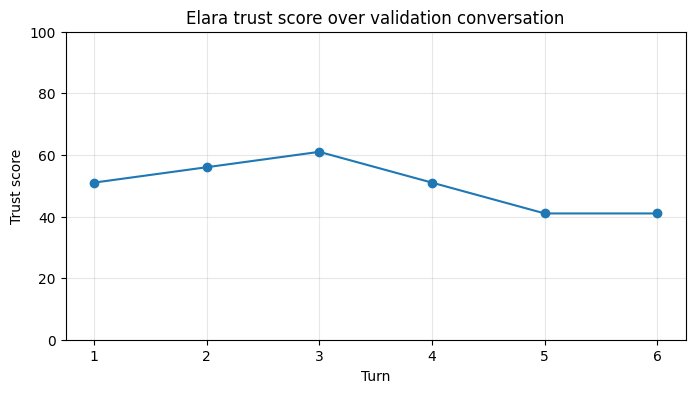

In [10]:
# The plot makes the relationship trajectory easy to inspect in the report.
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(trust_df) + 1), trust_df['trust_score'], marker='o')
plt.xticks(range(1, len(trust_df) + 1))
plt.ylim(0, 100)
plt.xlabel('Turn')
plt.ylabel('Trust score')
plt.title('Elara trust score over validation conversation')
plt.grid(True, alpha=0.3)
plt.show()

### Advice-following validation

This checks whether trust changes when the player follows or ignores advice. This is useful because otherwise trust would mostly be controlled by direct compliments and insults.

In [11]:
advice_agent = MemoryNPC()
advice_script = [
    'Can you help me recover my sword?',
    'I will go alone anyway',
    'Can you help me recover my sword?',
    'I will follow your advice and bring a torch',
]

advice_rows = []
for message in advice_script:
    advice_rows.append(advice_agent.generate_npc_response(message))

pd.DataFrame(advice_rows)[[
    'turn', 'player_input', 'intent', 'trust_before', 'trust_score',
    'trust_delta', 'advice_status', 'advice_delta', 'active_advice', 'new_advice'
]]

,turn,player_input,intent,trust_before,trust_score,trust_delta,advice_status,advice_delta,active_advice,new_advice
0,1,Can you help me recover my sword?,ask_help,50,50,0,none,0,None,"Recover the lost item carefully; bring light, ..."
1,2,I will go alone anyway,unknown,50,42,-8,ignored_advice,-8,"Recover the lost item carefully; bring light, ...",None
2,3,Can you help me recover my sword?,ask_help,42,42,0,none,0,None,"Recover the lost item carefully; bring light, ..."
3,4,I will follow your advice and bring a torch,unknown,42,45,3,followed_advice,3,"Recover the lost item carefully; bring light, ...",None


## 15. Response quality checks

A generated response cannot be fully judged by one automatic metric, so I use a small manual checklist. This is a practical choice for a 24-hour assignment because it checks the main risks without requiring a large human evaluation study. The checklist focuses on grounded generation: the NPC should use retrieved evidence when it is available and should not invent memories when it is not.

In [12]:
# Some response properties are best checked manually because a fluent LLM answer
# can still be ungrounded or out of character.
quality_checks = pd.DataFrame([
    {'check': 'Uses relevant memory when available', 'reason': 'The response prompt receives only top-k retrieved memories.'},
    {'check': 'Avoids unsupported memory claims', 'reason': 'The system prompt tells Elara not to claim memories unless they appear in retrieval.'},
    {'check': 'Tone reflects trust score', 'reason': 'The prompt includes current trust score and personality instructions.'},
    {'check': 'Stays in character', 'reason': 'The role prompt defines Elara as cautious, practical, direct, and a village blacksmith.'},
])
quality_checks

,check,reason
0,Uses relevant memory when available,The response prompt receives only top-k retrie...
1,Avoids unsupported memory claims,The system prompt tells Elara not to claim mem...
2,Tone reflects trust score,The prompt includes current trust score and pe...
3,Stays in character,"The role prompt defines Elara as cautious, pra..."


## 16. Results

After running the cells above, the main results to report are:

- Intent accuracy from the 20-case test set.
- Memory retrieval success rate from the 10 retrieval test cases.
- Keyword baseline retrieval success rate for comparison.
- Trust behavior from the table and plot.
- Response quality observations from the manual checklist.

The most important result for the design challenge is whether memory retrieval reaches at least 80% on the manually designed cases. The keyword baseline gives context: if FAISS performs better than simple word overlap, that supports the choice to use embeddings. If it does not, that would be an important error-analysis point.

In [13]:
# Final results table collects the main metrics in one place for the conclusion.
summary = pd.DataFrame([
    {'metric': 'Intent accuracy', 'value': f'{intent_accuracy:.0%}'},
    {'metric': 'Memory retrieval success rate', 'value': f'{retrieval_success_rate:.0%}'},
    {'metric': 'Keyword baseline retrieval success rate', 'value': f'{keyword_baseline_success_rate:.0%}'},
    {'metric': 'Final trust score in trust validation', 'value': trust_df.iloc[-1]['trust_score']},
])
summary

,metric,value
0,Intent accuracy,100%
1,Memory retrieval success rate,100%
2,Keyword baseline retrieval success rate,70%
3,Final trust score in trust validation,41


## 17. Error analysis

There are several likely sources of error:

- The LLM may classify intent inconsistently for vague messages.
- Memory extraction may save too much or too little. Saving too much creates noisy retrieval, while saving too little makes Elara forget important details.
- Vector retrieval can return irrelevant memories if the query is very short or semantically close to multiple memories.
- The NPC may still hallucinate if the response prompt is weak or if retrieved memories are ambiguous.
- Short memory questions like "what about it?" are difficult because they need conversation context, not only semantic memory retrieval.

## 18. Trustworthiness and quality improvement

The system improves trustworthiness in several ways. It uses structured prompts, restricted intent labels, fallback rules, a separate memory store, top-k retrieval instead of injecting every memory, manual validation tests, and deterministic trust scoring. These choices make the system easier to inspect and less dependent on a single large prompt.

For this assignment, trustworthiness means that I can explain where the answer came from. If Elara remembers the sword, I can inspect the stored memory and the retrieved memory list. If her tone changes, I can inspect the intent label and the trust rule. This does not make the system perfect, but it makes failures easier to diagnose than with a normal black-box chat prompt.

Future improvements could include a larger validation set, human ratings of response quality, persistent memory saved to disk, memory deletion or summarization, better evaluation of hallucination, and a more detailed relationship model with separate dimensions such as respect, fear, debt, and friendship.

## 19. Limitations

This is a small prototype, so it has clear limitations:

- The test set is small and manually designed.
- It depends on the OpenAI API, so it has cost and network requirements.
- It is not connected to a real game engine.
- Memory is runtime-only unless save/load behavior is added.
- The prototype is English-only.
- The trust model is simple and may not capture complex relationships.
- FAISS retrieval is helpful, but not a guarantee that the most important memory is always selected.

## 20. Conclusion

MemoryNPC demonstrates how an LLM can be extended with retrieval and structured logic to create a more reliable language-rich game interaction. Elara is still powered by a chat model for natural language, but her memory and trust behavior are not left entirely to the model. By combining LangChain, OpenAI embeddings, FAISS, prompt templates, intent labels, information extraction, and deterministic trust scoring, the project creates an NPC that is more believable, explainable, and testable than a normal chatbot.

The most important lesson is that the final answer is only one part of an NLP application. The useful system is the whole chain: language input, interpretation, memory extraction, vector retrieval, state update, grounded prompting, and validation.